**Unlocking Societal Trends in Aadhaar Enrollment and Updates**

Objectives: Identify meaningful patterns, trends, anomalies, or predictive indicators and translate them into clear insights or solution frameworks.

**Scope of Study**

This study analyzes Aadhaar enrollment data for Maharashtra from January 2025 to July 2026. The analysis focuses on identifying temporal trends, geographical distribution across districts and pincodes, and age-group-wise enrollment patterns. The findings are limited to the available enrollment dataset and do not include demographic updates, biometric updates, or comparisons with other states.

**Importing Libraries and Dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/content/ecd49b12-3084-4521-8f7e-ca8bf72069ba_b46440737d913ff5eb923a6883d0fb61.csv")

In [3]:
df.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,03-10-2025,Maharashtra,Mumbai,400003,0,1,0
1,03-10-2025,Maharashtra,Mumbai,400017,1,1,0
2,03-10-2025,Maharashtra,Mumbai,400022,2,1,1
3,03-10-2025,Maharashtra,Mumbai Suburban,400043,8,6,0
4,03-10-2025,Maharashtra,Mumbai Suburban,400053,1,1,0


In [4]:
df.tail()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
537484,20-07-2026,Maharashtra,Amravati,444709,1,0,0
537485,20-07-2026,Maharashtra,Amravati,444806,3,0,0
537486,20-07-2026,Maharashtra,Amravati,444807,1,0,0
537487,20-07-2026,Maharashtra,Amravati,444901,1,0,0
537488,20-07-2026,Maharashtra,Amravati,444906,2,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537489 entries, 0 to 537488
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   date            537489 non-null  object
 1   state           537489 non-null  object
 2   district        537489 non-null  object
 3   pincode         537489 non-null  int64 
 4   age_0_5         537489 non-null  int64 
 5   age_5_17        537489 non-null  int64 
 6   age_18_greater  537489 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 28.7+ MB


In [6]:
df.shape

(537489, 7)

In [7]:
df.columns.tolist()

['date',
 'state',
 'district',
 'pincode',
 'age_0_5',
 'age_5_17',
 'age_18_greater']

In [8]:
df.describe()

,pincode,age_0_5,age_5_17,age_18_greater
count,537489.000000,537489.000000,537489.000000,537489.000000
mean,421592.730173,3.300415,1.259075,0.106544
std,13701.903596,4.900449,3.174686,0.660821
min,400001.000000,0.000000,0.000000,0.000000
25%,413115.000000,1.000000,0.000000,0.000000
50%,416505.000000,2.000000,0.000000,0.000000
75%,431513.000000,4.000000,1.000000,0.000000
max,445402.000000,234.000000,252.000000,62.000000


**Data Cleaning**

In [9]:
#Checking if there is any null by getting its sum
df.isnull().sum()

,0
date,0
state,0
district,0
pincode,0
age_0_5,0
age_5_17,0
age_18_greater,0


In [10]:
#Checking duplicate values
df.duplicated().sum()

np.int64(43974)

In [11]:
#Converting date column datatype (object to date)
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y")

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537489 entries, 0 to 537488
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date            537489 non-null  datetime64[ns]
 1   state           537489 non-null  object        
 2   district        537489 non-null  object        
 3   pincode         537489 non-null  int64         
 4   age_0_5         537489 non-null  int64         
 5   age_5_17        537489 non-null  int64         
 6   age_18_greater  537489 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(2)
memory usage: 28.7+ MB


**Feature Engineering**

In [13]:
#Creating total enrollments
df["total_enrollment"] = (df["age_0_5"]+ df["age_5_17"]+ df["age_18_greater"])

In [14]:
df.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,total_enrollment
0,2025-10-03,Maharashtra,Mumbai,400003,0,1,0,1
1,2025-10-03,Maharashtra,Mumbai,400017,1,1,0,2
2,2025-10-03,Maharashtra,Mumbai,400022,2,1,1,4
3,2025-10-03,Maharashtra,Mumbai Suburban,400043,8,6,0,14
4,2025-10-03,Maharashtra,Mumbai Suburban,400053,1,1,0,2


In [15]:
print(df["date"].min())
print(df["date"].max())

2025-01-01 00:00:00
2026-07-20 00:00:00


In [16]:
#Extracting year
df["year"] = df["date"].dt.year

In [17]:
#Extracting month
df["month"] = df["date"].dt.month

In [18]:
#Extracting month name
df["month_name"] = df["date"].dt.month_name()

In [19]:
#Extracting day
df["day"] = df["date"].dt.day

In [20]:
#Extracting quarter
df["quarter"] = df["date"].dt.quarter

In [21]:
df.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,total_enrollment,year,month,month_name,day,quarter
0,2025-10-03,Maharashtra,Mumbai,400003,0,1,0,1,2025,10,October,3,4
1,2025-10-03,Maharashtra,Mumbai,400017,1,1,0,2,2025,10,October,3,4
2,2025-10-03,Maharashtra,Mumbai,400022,2,1,1,4,2025,10,October,3,4
3,2025-10-03,Maharashtra,Mumbai Suburban,400043,8,6,0,14,2025,10,October,3,4
4,2025-10-03,Maharashtra,Mumbai Suburban,400053,1,1,0,2,2025,10,October,3,4


**Explonatory Data Analysis**

In [22]:
#Checking number of unique districts
print("Number of Districts:", df["district"].nunique())

Number of Districts: 36


In [23]:
#Checking number of unique pincode
print("Number of Pincodes:", df["pincode"].nunique())

Number of Pincodes: 1604


In [24]:
#Date range
print("Start Date:", df["date"].min())
print("End Date:", df["date"].max())

Start Date: 2025-01-01 00:00:00
End Date: 2026-07-20 00:00:00


In [25]:
df["total_enrollment"].describe()

,total_enrollment
count,537489.000000
mean,4.666034
std,7.265569
min,1.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,386.000000


In [26]:
#Checking total enrollment by age group
print("Age 0-5:", df["age_0_5"].sum())
print("Age 5-17:", df["age_5_17"].sum())
print("Age 18+:", df["age_18_greater"].sum())

Age 0-5: 1773937
Age 5-17: 676739
Age 18+: 57266


**Monthly Enrollment Trend**

In [27]:
df["year_month"] = df["date"].dt.to_period("M").astype(str)

In [28]:
monthly_enrollment = (df.groupby("year_month")["total_enrollment"].sum().reset_index())
monthly_enrollment.head()

,year_month,total_enrollment
0,2025-01,104318
1,2025-02,241884
2,2025-03,115573
3,2025-04,101029
4,2025-05,100839


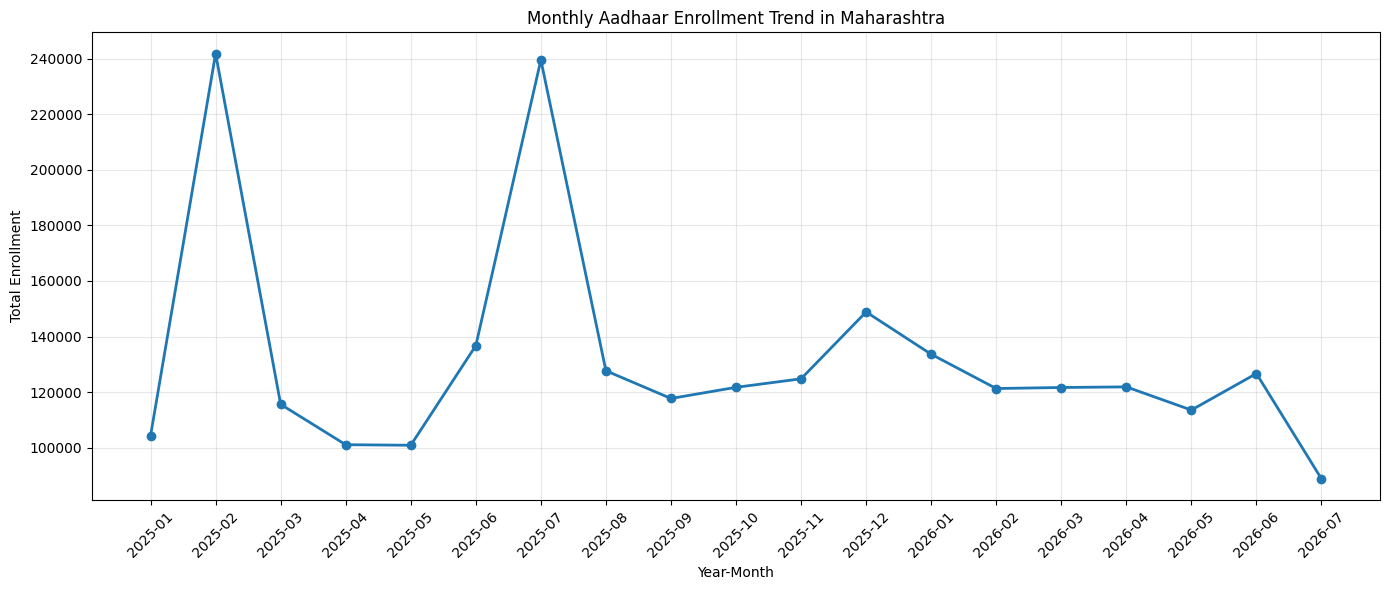

In [29]:
#Visualising monthly enrollment trend
plt.figure(figsize=(14,6))
plt.plot(monthly_enrollment["year_month"],monthly_enrollment["total_enrollment"],marker="o",linewidth=2)
plt.title("Monthly Aadhaar Enrollment Trend in Maharashtra")
plt.xlabel("Year-Month")
plt.ylabel("Total Enrollment")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** Enrollment activity remained dynamic throughout the study period, with notable peaks during February and July 2025.

**District-wise Total Enrollment**

In [30]:
district_enrollment = (df.groupby("district")["total_enrollment"].sum().sort_values(ascending=False).reset_index())
district_enrollment.head()

,district,total_enrollment
0,Pune,233827
1,Thane,192332
2,Mumbai Suburban,170285
3,Nashik,168303
4,Chhatrapati Sambhajinagar,108732


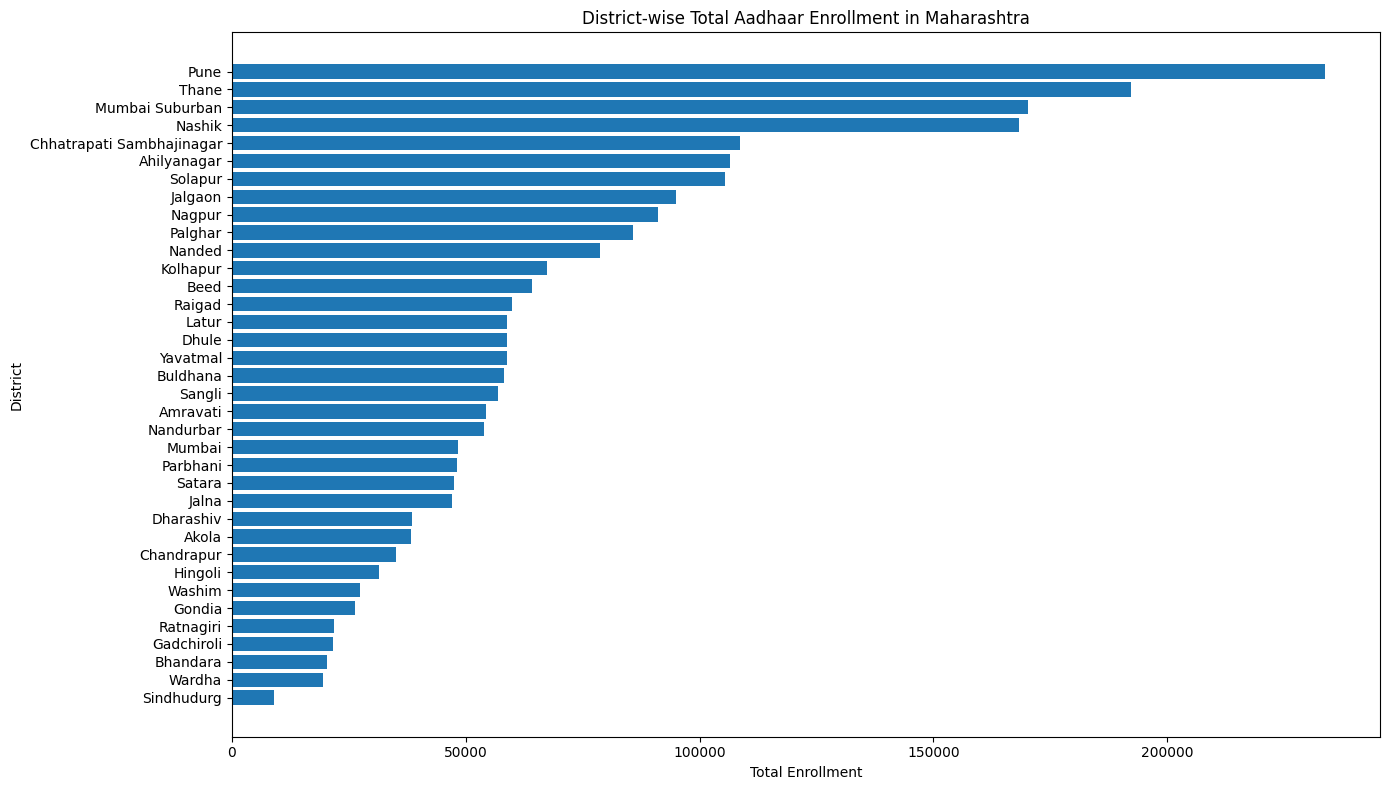

In [31]:
plt.figure(figsize=(14,8))
plt.barh(district_enrollment["district"],district_enrollment["total_enrollment"])
plt.title("District-wise Total Aadhaar Enrollment in Maharashtra")
plt.xlabel("Total Enrollment")
plt.ylabel("District")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Insight:** Aadhaar enrollment shows significant geographical variation across Maharashtra, with Thane, Mumbai Suburban, and Nashik recording the highest enrollments, while Sindhudurg, Wardha, and Bhandara have comparatively lower enrollment counts.

**Age Group Distribution**

In [32]:
age_totals = { "0-5 Years": df["age_0_5"].sum(),"5-17 Years": df["age_5_17"].sum(),"18+ Years": df["age_18_greater"].sum()}
age_df = pd.DataFrame(age_totals.items(),columns=["Age Group", "Total Enrollment"])
age_df

,Age Group,Total Enrollment
0,0-5 Years,1773937
1,5-17 Years,676739
2,18+ Years,57266


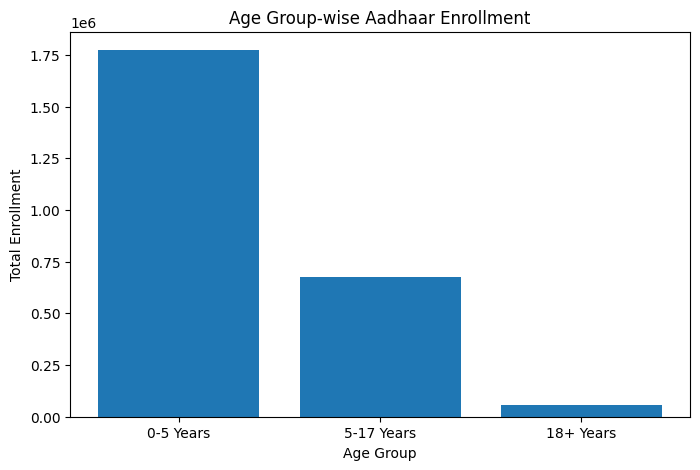

In [33]:
plt.figure(figsize=(8,5))
plt.bar(age_df["Age Group"],age_df["Total Enrollment"])
plt.title("Age Group-wise Aadhaar Enrollment")
plt.xlabel("Age Group")
plt.ylabel("Total Enrollment")
plt.show()

**Insight:** Aadhaar enrollment is predominantly concentrated in the 0–5 years age group, followed by 5–17 years, while the 18+ years category accounts for the smallest share of enrollments.

**Quartely Enrollment Trend**

In [34]:
quarterly_enrollment = (df.groupby(["year", "quarter"])["total_enrollment"].sum().reset_index())
quarterly_enrollment["Year-Quarter"] = ( quarterly_enrollment["year"].astype(str)+ "-Q" + quarterly_enrollment["quarter"].astype(str))

quarterly_enrollment

,year,quarter,total_enrollment,Year-Quarter
0,2025,1,461775,2025-Q1
1,2025,2,338591,2025-Q2
2,2025,3,484973,2025-Q3
3,2025,4,395310,2025-Q4
4,2026,1,376515,2026-Q1
5,2026,2,362029,2026-Q2
6,2026,3,88749,2026-Q3


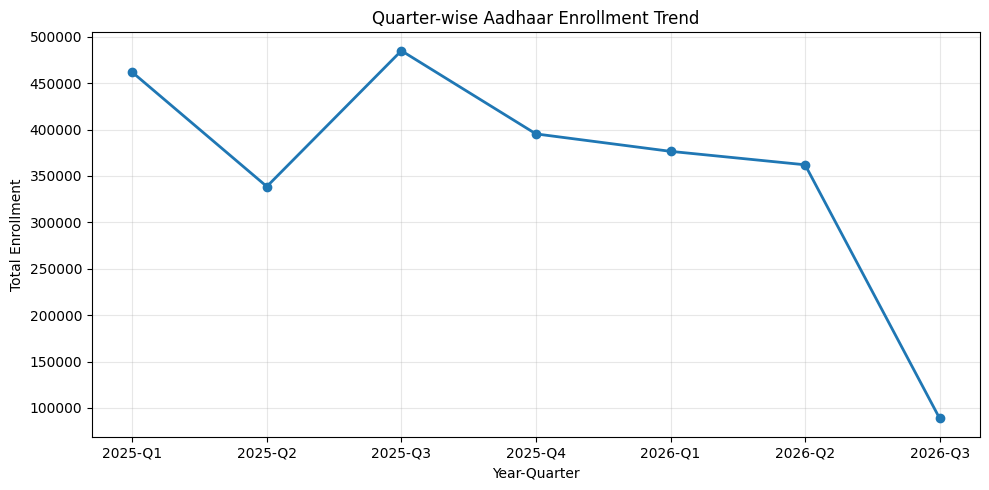

In [35]:
plt.figure(figsize=(10,5))
plt.plot(quarterly_enrollment["Year-Quarter"],quarterly_enrollment["total_enrollment"],marker="o",linewidth=2)
plt.title("Quarter-wise Aadhaar Enrollment Trend")
plt.xlabel("Year-Quarter")
plt.ylabel("Total Enrollment")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** Quarterly analysis highlights changing enrollment demand across the study period, with 2025-Q3 recording the highest overall enrollment among complete quarters.

Note:2026-Q3 contains data only up to 20 July 2026 and does not represent a complete quarter.

**Top Pincodes by Adhaar Enrollment**

In [36]:
top_pincodes = (df.groupby("pincode")["total_enrollment"].sum().sort_values(ascending=False).head(10).reset_index())

top_pincodes

,pincode,total_enrollment
0,431001,34599
1,423203,28348
2,421302,23556
3,400612,16057
4,400043,15187
5,410206,14645
6,421301,13047
7,401107,11072
8,431203,10572
9,413512,10375


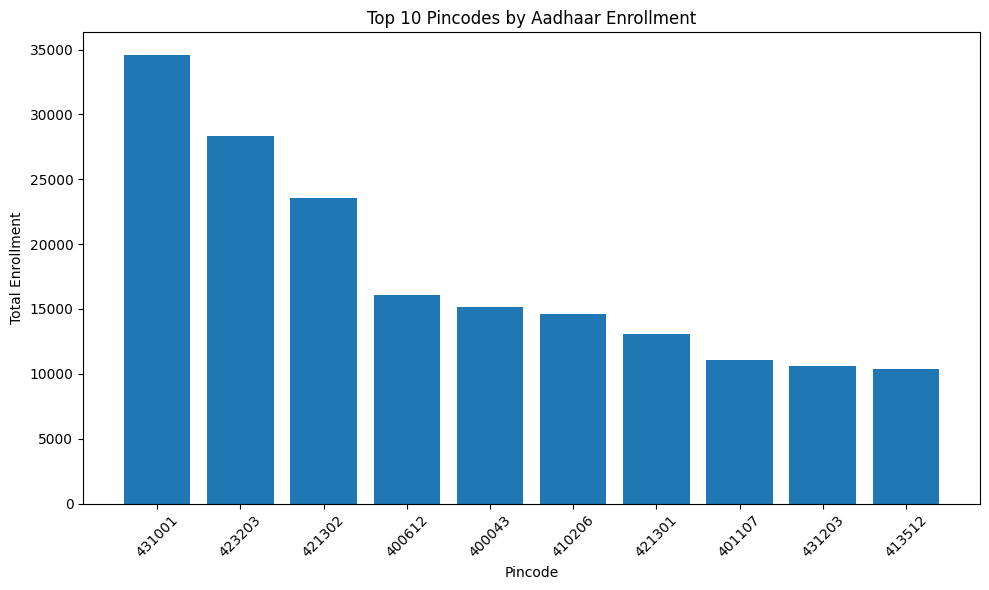

In [37]:
plt.figure(figsize=(10,6))
plt.bar(top_pincodes["pincode"].astype(str),top_pincodes["total_enrollment"])
plt.title("Top 10 Pincodes by Aadhaar Enrollment")
plt.xlabel("Pincode")
plt.ylabel("Total Enrollment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** A small number of pincodes contribute significantly to Aadhaar enrollment, indicating localized areas with consistently higher enrollment activity.

**Monthly Enrollment Heatmap by District**

In [38]:
heatmap_data = (df.groupby(["district", "year_month"])["total_enrollment"].sum().unstack(fill_value=0))
heatmap_data.head()

year_month,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07
district,,,,,,,,,,,,,,,,,,,
Ahilyanagar,4338,7999,3692,3878,3025,4494,8585,5036,4261,4182,4032,9148,8863,7032,6545,5744,5519,6223,3994
Akola,1845,3872,1953,1324,1733,2432,3529,2341,1705,1858,1881,2193,2045,1860,1621,1599,1571,1600,1390
Amravati,1735,4489,2691,2355,2621,3118,5692,3207,2549,2573,2415,3429,2797,2390,2424,2473,2269,2799,2412
Beed,2248,5405,3001,2641,2946,4274,7728,3771,2929,3259,3124,3189,2747,2493,2551,2675,2764,3441,2918
Bhandara,541,2354,1222,1012,966,1192,1477,802,713,733,843,1391,1234,1075,1210,974,875,897,746


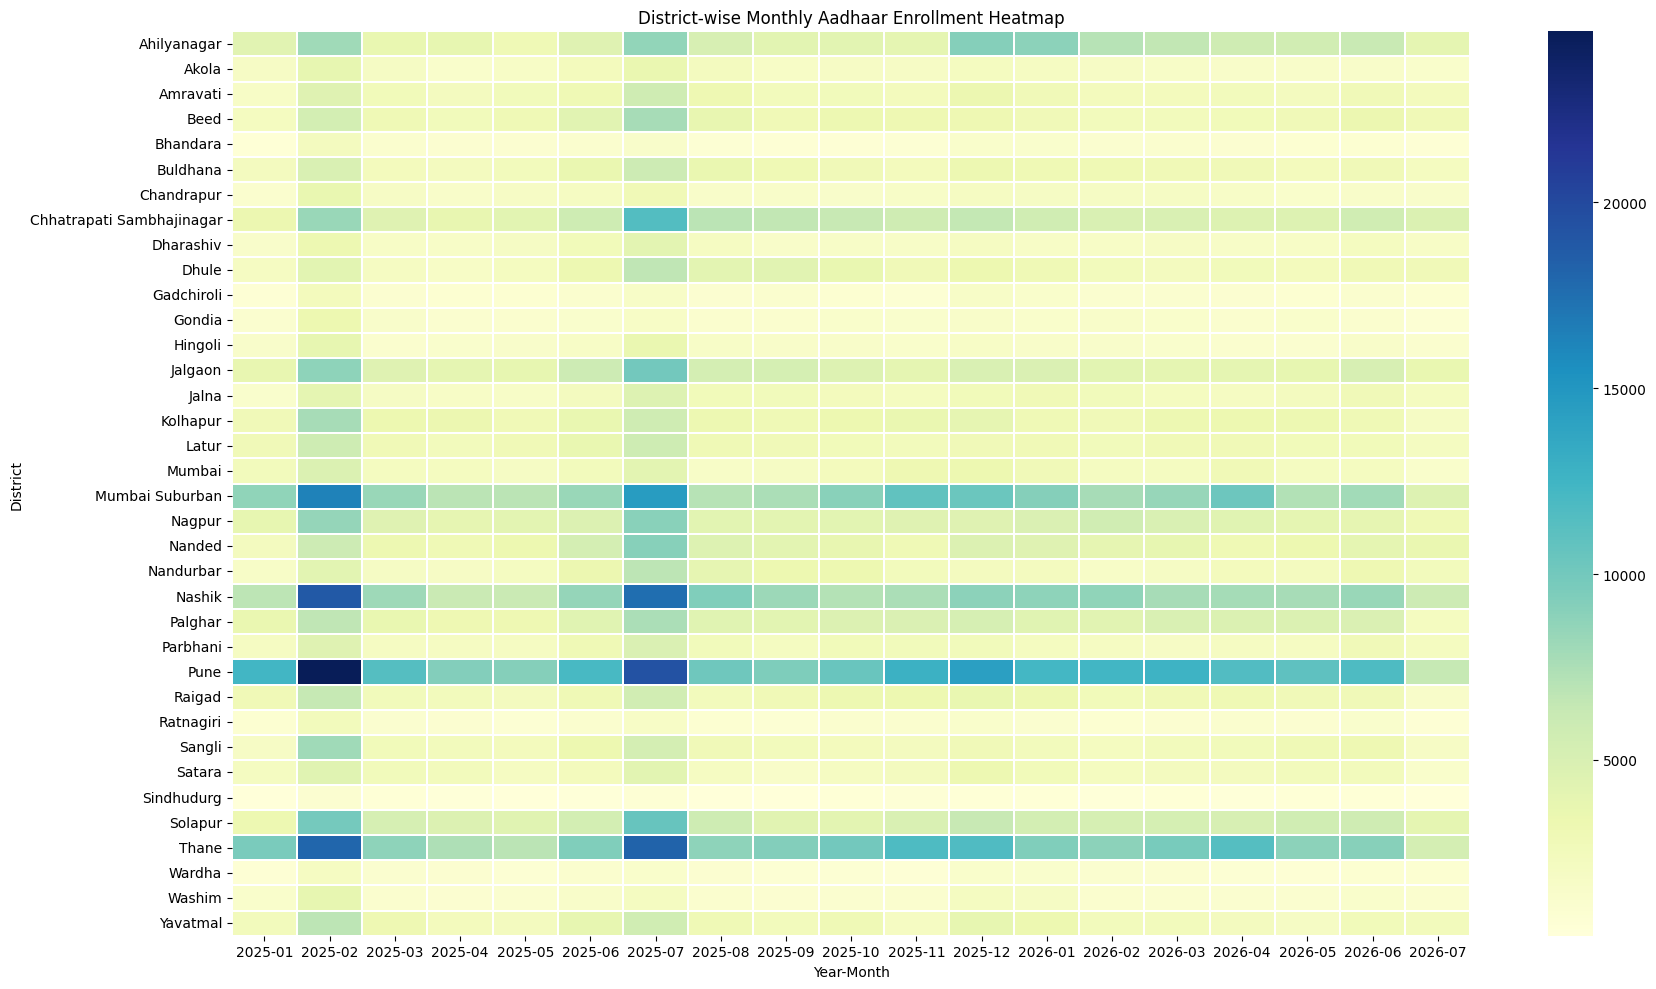

In [39]:
plt.figure(figsize=(18,10))
sns.heatmap(heatmap_data,cmap="YlGnBu",linewidths=0.3)
plt.title("District-wise Monthly Aadhaar Enrollment Heatmap")
plt.xlabel("Year-Month")
plt.ylabel("District")
plt.tight_layout()
plt.show()

**Insight:** Aadhaar enrollment intensity varies across both districts and months, highlighting districts with consistently high enrollment activity and periods of increased demand.

**Month over month growth rate analysis**

In [40]:
monthly_growth = (df.groupby("year_month")["total_enrollment"].sum()
  .reset_index()
)

monthly_growth["MoM_Growth(%)"] = (
    monthly_growth["total_enrollment"].pct_change() * 100
)

monthly_growth.head()

,year_month,total_enrollment,MoM_Growth(%)
0,2025-01,104318,NaN
1,2025-02,241884,131.871777
2,2025-03,115573,-52.219659
3,2025-04,101029,-12.584254
4,2025-05,100839,-0.188065


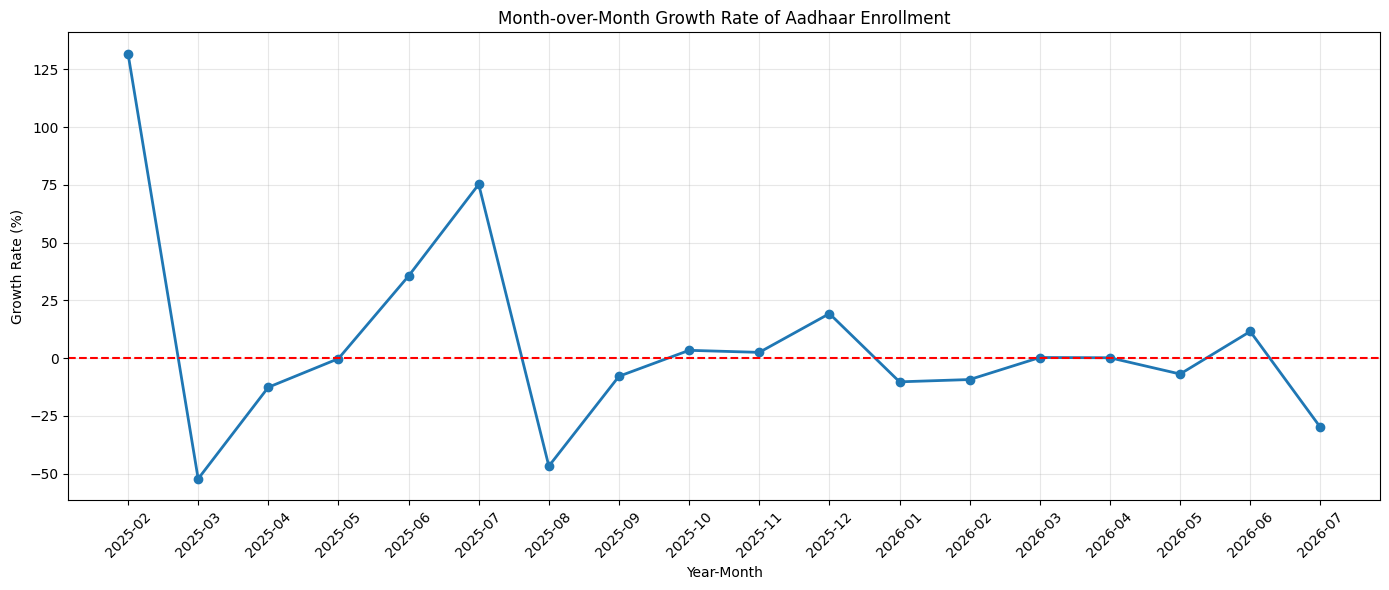

In [41]:
plt.figure(figsize=(14,6))
plt.plot(monthly_growth["year_month"],monthly_growth["MoM_Growth(%)"],marker="o",linewidth=2)
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Month-over-Month Growth Rate of Aadhaar Enrollment")
plt.xlabel("Year-Month")
plt.ylabel("Growth Rate (%)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** The month-over-month growth rate fluctuates throughout the study period, indicating periods of rapid enrollment growth as well as temporary declines.

**Top 10 Highest Enrollment Days**

In [42]:
top_days = (df.groupby("date")["total_enrollment"].sum().sort_values(ascending=False).head(10).reset_index())

top_days

,date,total_enrollment
0,2025-02-05,35524
1,2025-02-18,32794
2,2025-07-11,24200
3,2025-06-24,24185
4,2025-02-06,22988
5,2025-02-03,21286
6,2025-03-20,20896
7,2025-07-09,18897
8,2025-10-08,18636
9,2025-02-04,18333


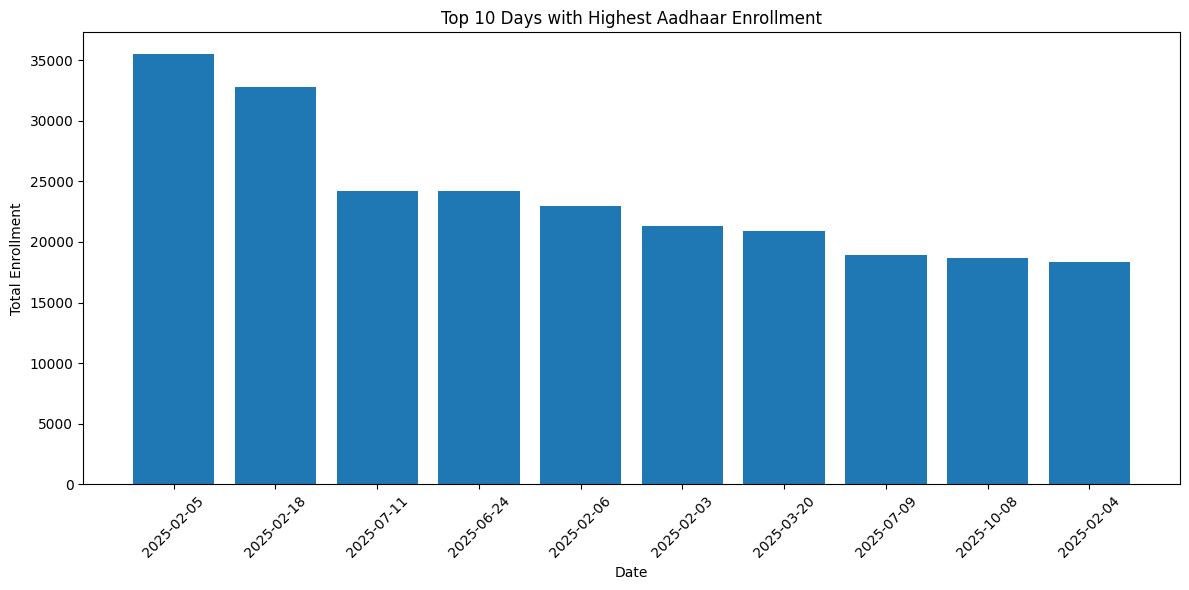

In [43]:
plt.figure(figsize=(12,6))
plt.bar(top_days["date"].dt.strftime("%Y-%m-%d"),top_days["total_enrollment"])
plt.title("Top 10 Days with Highest Aadhaar Enrollment")
plt.xlabel("Date")
plt.ylabel("Total Enrollment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** A limited number of days recorded exceptionally high Aadhaar enrollment, indicating periods of concentrated enrollment activity that may correspond to special campaigns or increased public demand.

**Anomaly Detection**

In [44]:
monthly = (df.groupby("year_month")["total_enrollment"].sum().reset_index())

In [45]:
from scipy.stats import zscore
monthly["z_score"] = zscore(monthly["total_enrollment"])

In [46]:
anomalies = monthly[abs(monthly["z_score"]) > 2]
anomalies

,year_month,total_enrollment,z_score
1,2025-02,241884,2.770964
6,2025-07,239620,2.713874


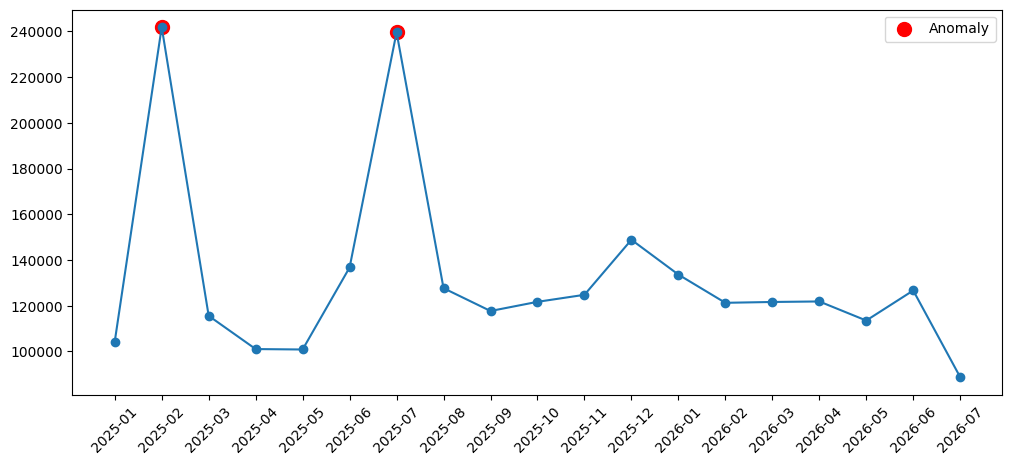

In [47]:
plt.figure(figsize=(12,5))
plt.plot(monthly["year_month"],monthly["total_enrollment"],marker="o")
plt.scatter(anomalies["year_month"],anomalies["total_enrollment"],color="red",s=100,label="Anomaly")
plt.legend()
plt.xticks(rotation=45)
plt.show()

**Analysis Methodology**
* Data Collection
* Data Preparation
* Feature Engineering
* Exploratory Data Analysis
* Trend Identification
* Interpretation & Recommendations

## Key Findings

- The dataset contains Aadhaar enrollment records for Maharashtra from **January 2025 to July 2026**.
- No missing values or duplicate records were found, indicating good data quality.
- Aadhaar enrollment varied across different months, with noticeable peaks during **February 2025** and **July 2025**.
- Quarterly analysis showed fluctuations in enrollment, with **2025-Q3** recording the highest enrollment among the complete quarters analyzed.
- The **0–5 years** age group accounted for the highest number of enrollments, followed by the **5–17 years** age group, while enrollments for individuals aged **18 years and above** were comparatively lower.
- Enrollment activity varied considerably across districts, with **Thane, Mumbai Suburban, and Nashik** contributing the highest enrollment volumes.
- A small number of pincodes accounted for a significant share of total enrollments, indicating localized areas of high enrollment activity.
- The month-over-month growth analysis showed periods of both positive and negative growth, reflecting changing enrollment demand over time.

## Business Recommendations

- Increase enrollment resources and staffing during months with historically high enrollment activity.
- Conduct awareness campaigns in districts with comparatively lower enrollment to improve Aadhaar coverage.
- Monitor high-demand pincodes regularly to ensure adequate infrastructure and reduce waiting times.
- Develop targeted enrollment strategies for age groups with lower participation where appropriate.
- Continuously monitor monthly enrollment trends to identify unusual increases or decreases and investigate their causes.
- Implement periodic monitoring dashboards to continuously track enrollment trends across districts and age groups.

## Conclusion

This project analyzed Aadhaar enrollment data for Maharashtra to identify temporal, geographical, and demographic enrollment patterns. Through data cleaning, feature engineering, and exploratory data analysis, several meaningful trends were identified, including monthly enrollment variations, district-level differences, pincode-wise distribution, and age-group participation. The findings demonstrate how data analytics can support evidence-based planning and resource allocation for Aadhaar enrollment services. The methodology developed in this project can be extended to other states or larger datasets to enable broader policy analysis and decision-making.